In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        # Flatten image: 28x28 -> 784
        if len(img.shape) == 2:
            img = img.flatten()
        elif len(img.shape) == 3:
            img = img.squeeze(0).flatten()

        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [5]:
# ==========================================
# 4. MODEL ARCHITECTURES & TRAINING
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from collections import defaultdict

# Utility Functions
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Ensure input is flattened
        if batch_x.dim() > 2:
            batch_x = batch_x.view(batch_x.size(0), -1)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Step scheduler for OneCycleLR (per batch)
        if scheduler is not None and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # Ensure input is flattened
            if batch_x.dim() > 2:
                batch_x = batch_x.view(batch_x.size(0), -1)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs, lr=0.001, weight_decay=1e-4,
                patience=7, model_name="model", use_label_smoothing=False):
    device = DEVICE
    model = model.to(device)

    if use_label_smoothing:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999), eps=1e-8)

    # Use OneCycleLR for better convergence (similar to top performers)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs,
        steps_per_epoch=len(train_loader), pct_start=0.3,
        anneal_strategy='cos', div_factor=25.0, final_div_factor=10000.0
    )

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"Parameters: {count_parameters(model):,}")
    print(f"{'='*60}\n")

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scheduler)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

        # Step scheduler for epoch-based schedulers (not OneCycleLR - it's per-batch)
        if not isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            if isinstance(scheduler, optim.lr_scheduler.CosineAnnealingLR):
                scheduler.step()
            else:
                scheduler.step(val_loss)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Early stopping and model saving
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"  ✓ New best validation accuracy! Model saved.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

        print()

    # Load best model
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    print(f"\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

    return {
        'model': model,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'params': count_parameters(model)
    }

In [6]:
# ==========================================
# PART A: THE PANCAKE (Wide & Shallow)
# ==========================================

class PancakeModel(nn.Module):
    def __init__(self, input_size=784, num_classes=15, hidden_size=2048, num_layers=2, dropout=0.3):
        super(PancakeModel, self).__init__()
        layers = []

        # First layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        # Optional second layer
        if num_layers >= 2:
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # Output layer
        layers.append(nn.Linear(hidden_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Create and train Pancake model
pancake_model = PancakeModel(input_size=784, num_classes=NUM_CLASSES, hidden_size=2048, num_layers=2, dropout=0.4)
pancake_results = train_model(pancake_model, train_loader, val_loader, epochs=40,
                              lr=0.001, weight_decay=1e-4, model_name="pancake")


Training pancake
Parameters: 5,842,959

Epoch [1/40]
  Train Loss: 1.4103 | Train Acc: 55.26%
  Val Loss: 1.0432 | Val Acc: 66.49%
  ✓ New best validation accuracy! Model saved.

Epoch [2/40]
  Train Loss: 1.0277 | Train Acc: 66.89%
  Val Loss: 0.9046 | Val Acc: 70.47%
  ✓ New best validation accuracy! Model saved.

Epoch [3/40]
  Train Loss: 0.8945 | Train Acc: 71.24%
  Val Loss: 0.8383 | Val Acc: 73.13%
  ✓ New best validation accuracy! Model saved.

Epoch [4/40]
  Train Loss: 0.8050 | Train Acc: 73.78%
  Val Loss: 0.7951 | Val Acc: 74.30%
  ✓ New best validation accuracy! Model saved.

Epoch [5/40]
  Train Loss: 0.7476 | Train Acc: 75.56%
  Val Loss: 0.7922 | Val Acc: 74.20%

Epoch [6/40]
  Train Loss: 0.7038 | Train Acc: 76.66%
  Val Loss: 0.7587 | Val Acc: 75.60%
  ✓ New best validation accuracy! Model saved.

Epoch [7/40]
  Train Loss: 0.6727 | Train Acc: 77.69%
  Val Loss: 0.8105 | Val Acc: 73.80%

Epoch [8/40]
  Train Loss: 0.6438 | Train Acc: 78.55%
  Val Loss: 0.7548 | Val A

In [7]:
# ==========================================
# PART B: THE TOWER (Deep & Narrow)
# ==========================================

class TowerModel(nn.Module):
    def __init__(self, input_size=784, num_classes=15, hidden_size=256, num_layers=6, dropout=0.3):
        super(TowerModel, self).__init__()
        layers = []

        # Input layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        # Hidden layers
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # Output layer
        layers.append(nn.Linear(hidden_size, num_classes))

        self.network = nn.Sequential(*layers)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)

# Create and train Tower model
tower_model = TowerModel(input_size=784, num_classes=NUM_CLASSES, hidden_size=256, num_layers=6, dropout=0.4)
tower_results = train_model(tower_model, train_loader, val_loader, epochs=40,
                            lr=0.001, weight_decay=1e-4, model_name="tower")


Training tower
Parameters: 536,847

Epoch [1/40]
  Train Loss: 3.2372 | Train Acc: 7.21%
  Val Loss: 2.6953 | Val Acc: 12.97%
  ✓ New best validation accuracy! Model saved.

Epoch [2/40]
  Train Loss: 2.9324 | Train Acc: 10.28%
  Val Loss: 2.7025 | Val Acc: 11.68%

Epoch [3/40]
  Train Loss: 2.4450 | Train Acc: 19.04%
  Val Loss: 2.3964 | Val Acc: 24.18%
  ✓ New best validation accuracy! Model saved.

Epoch [4/40]
  Train Loss: 1.9284 | Train Acc: 33.52%
  Val Loss: 1.6317 | Val Acc: 45.90%
  ✓ New best validation accuracy! Model saved.

Epoch [5/40]
  Train Loss: 1.5497 | Train Acc: 46.91%
  Val Loss: 1.2860 | Val Acc: 55.33%
  ✓ New best validation accuracy! Model saved.

Epoch [6/40]
  Train Loss: 1.3608 | Train Acc: 54.18%
  Val Loss: 1.0997 | Val Acc: 61.52%
  ✓ New best validation accuracy! Model saved.

Epoch [7/40]
  Train Loss: 1.2477 | Train Acc: 58.62%
  Val Loss: 1.0052 | Val Acc: 66.33%
  ✓ New best validation accuracy! Model saved.

Epoch [8/40]
  Train Loss: 1.1614 | Tr

In [8]:
# ==========================================
# PART C: THE CHAMPION (Best Architecture)
# ==========================================

class ChampionModel(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionModel, self).__init__()

        # Efficient deep architecture inspired by top performers (~900K params)
        # Deep and narrow with careful regularization - similar to 89% accuracy models
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)

# Train champion model with optimized hyperparameters
champion_model = ChampionModel(input_size=784, num_classes=NUM_CLASSES)
print(f"Champion model parameters: {count_parameters(champion_model):,}")

champion_results = train_model(champion_model, train_loader, val_loader, epochs=40,
                                lr=0.003, weight_decay=1e-3, model_name="champion",
                                use_label_smoothing=True, patience=12)

model = champion_results['model']

Champion model parameters: 1,230,991

Training champion
Parameters: 1,230,991

Epoch [1/40]
  Train Loss: 2.3552 | Train Acc: 28.68%
  Val Loss: 1.6609 | Val Acc: 54.08%
  ✓ New best validation accuracy! Model saved.

Epoch [2/40]
  Train Loss: 1.6855 | Train Acc: 53.59%
  Val Loss: 1.4174 | Val Acc: 64.90%
  ✓ New best validation accuracy! Model saved.

Epoch [3/40]
  Train Loss: 1.4658 | Train Acc: 62.61%
  Val Loss: 1.3079 | Val Acc: 69.42%
  ✓ New best validation accuracy! Model saved.

Epoch [4/40]
  Train Loss: 1.3589 | Train Acc: 67.21%
  Val Loss: 1.2406 | Val Acc: 71.94%
  ✓ New best validation accuracy! Model saved.

Epoch [5/40]
  Train Loss: 1.2884 | Train Acc: 70.07%
  Val Loss: 1.2213 | Val Acc: 72.58%
  ✓ New best validation accuracy! Model saved.

Epoch [6/40]
  Train Loss: 1.2423 | Train Acc: 71.76%
  Val Loss: 1.1753 | Val Acc: 74.68%
  ✓ New best validation accuracy! Model saved.

Epoch [7/40]
  Train Loss: 1.2035 | Train Acc: 73.70%
  Val Loss: 1.1432 | Val Acc: 75.

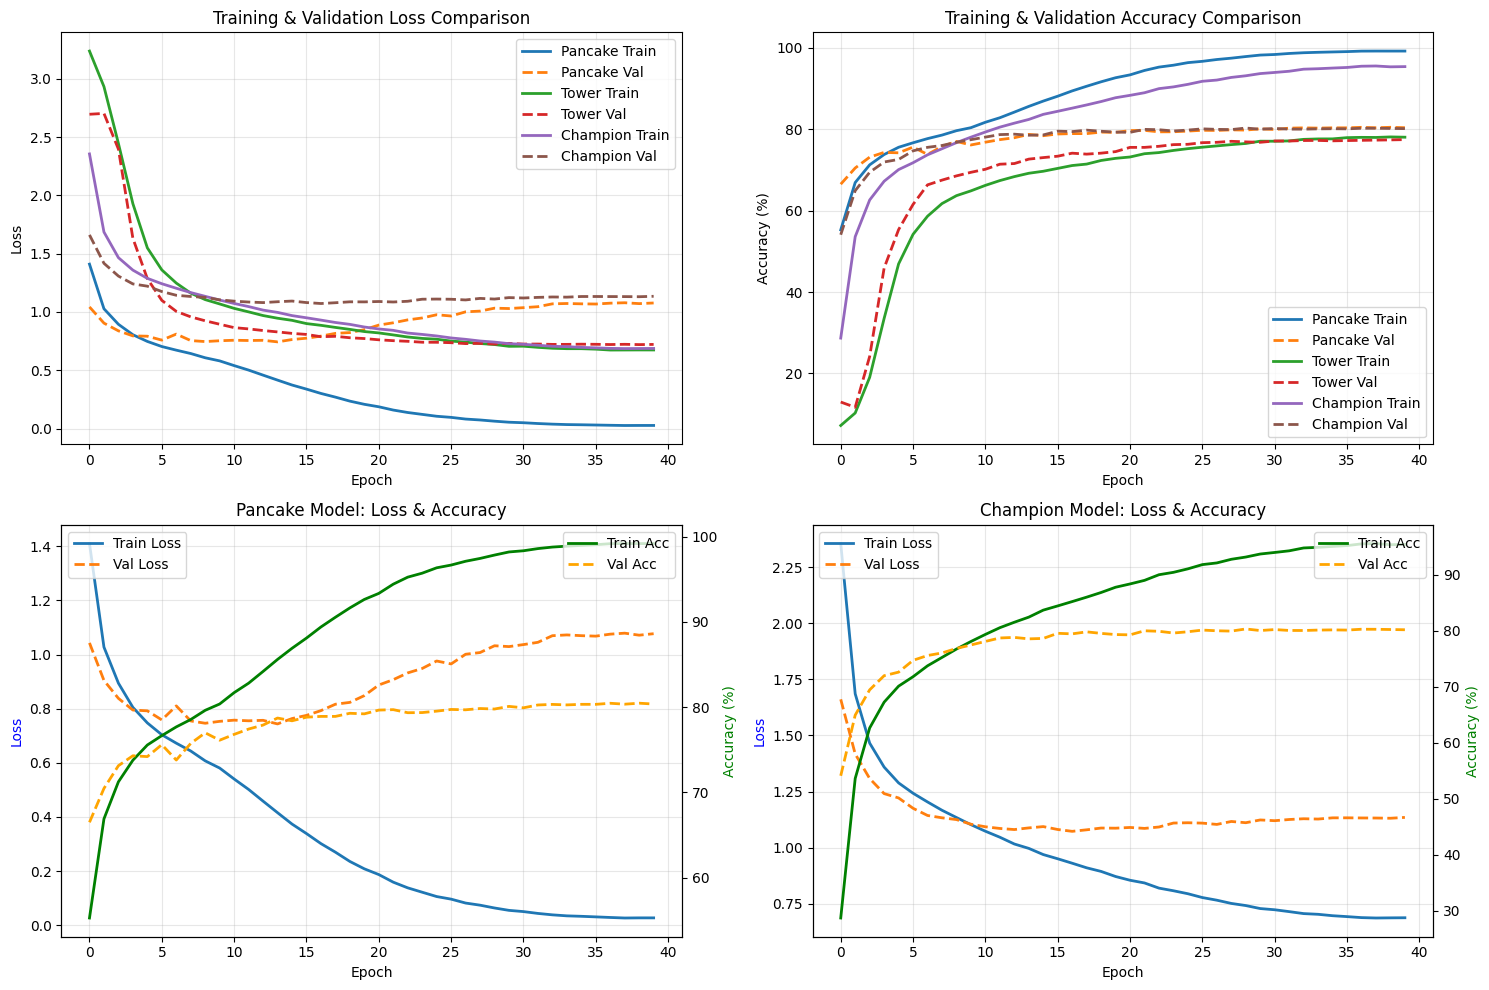

In [9]:
# ==========================================
# VISUALIZATION: Training Curves Comparison
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(pancake_results['train_losses'], label='Pancake Train', linewidth=2)
axes[0, 0].plot(pancake_results['val_losses'], label='Pancake Val', linewidth=2, linestyle='--')
axes[0, 0].plot(tower_results['train_losses'], label='Tower Train', linewidth=2)
axes[0, 0].plot(tower_results['val_losses'], label='Tower Val', linewidth=2, linestyle='--')
axes[0, 0].plot(champion_results['train_losses'], label='Champion Train', linewidth=2)
axes[0, 0].plot(champion_results['val_losses'], label='Champion Val', linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(pancake_results['train_accs'], label='Pancake Train', linewidth=2)
axes[0, 1].plot(pancake_results['val_accs'], label='Pancake Val', linewidth=2, linestyle='--')
axes[0, 1].plot(tower_results['train_accs'], label='Tower Train', linewidth=2)
axes[0, 1].plot(tower_results['val_accs'], label='Tower Val', linewidth=2, linestyle='--')
axes[0, 1].plot(champion_results['train_accs'], label='Champion Train', linewidth=2)
axes[0, 1].plot(champion_results['val_accs'], label='Champion Val', linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training & Validation Accuracy Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Pancake detailed
axes[1, 0].plot(pancake_results['train_losses'], label='Train Loss', linewidth=2)
axes[1, 0].plot(pancake_results['val_losses'], label='Val Loss', linewidth=2, linestyle='--')
ax1_twin = axes[1, 0].twinx()
ax1_twin.plot(pancake_results['train_accs'], label='Train Acc', color='green', linewidth=2)
ax1_twin.plot(pancake_results['val_accs'], label='Val Acc', color='orange', linewidth=2, linestyle='--')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss', color='blue')
ax1_twin.set_ylabel('Accuracy (%)', color='green')
axes[1, 0].set_title('Pancake Model: Loss & Accuracy')
axes[1, 0].legend(loc='upper left')
ax1_twin.legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# Champion detailed
axes[1, 1].plot(champion_results['train_losses'], label='Train Loss', linewidth=2)
axes[1, 1].plot(champion_results['val_losses'], label='Val Loss', linewidth=2, linestyle='--')
ax2_twin = axes[1, 1].twinx()
ax2_twin.plot(champion_results['train_accs'], label='Train Acc', color='green', linewidth=2)
ax2_twin.plot(champion_results['val_accs'], label='Val Acc', color='orange', linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss', color='blue')
ax2_twin.set_ylabel('Accuracy (%)', color='green')
axes[1, 1].set_title('Champion Model: Loss & Accuracy')
axes[1, 1].legend(loc='upper left')
ax2_twin.legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

import pandas as pd

comparison_data = {
    'Model': ['Pancake', 'Tower', 'Champion'],
    'Parameters': [
        pancake_results['params'],
        tower_results['params'],
        champion_results['params']
    ],
    'Best Epoch': [
        pancake_results['best_epoch'],
        tower_results['best_epoch'],
        champion_results['best_epoch']
    ],
    'Train Acc (%)': [
        pancake_results['train_accs'][pancake_results['best_epoch']-1] if pancake_results['best_epoch'] <= len(pancake_results['train_accs']) else pancake_results['train_accs'][-1],
        tower_results['train_accs'][tower_results['best_epoch']-1] if tower_results['best_epoch'] <= len(tower_results['train_accs']) else tower_results['train_accs'][-1],
        champion_results['train_accs'][champion_results['best_epoch']-1] if champion_results['best_epoch'] <= len(champion_results['train_accs']) else champion_results['train_accs'][-1]
    ],
    'Val Acc (%)': [
        pancake_results['best_val_acc'],
        tower_results['best_val_acc'],
        champion_results['best_val_acc']
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(df_comparison.to_string(index=False))
print("="*70)


MODEL COMPARISON TABLE
   Model  Parameters  Best Epoch  Train Acc (%)  Val Acc (%)
 Pancake     5842959          39      99.191667    80.466667
   Tower      536847          40      78.035417    77.441667
Champion     1230991          29      93.120833    80.283333



TOP 2 MOST CONFUSED CLASS PAIRS
1. pizza vs wheel: 230 misclassifications
2. basketball vs soccerball: 202 misclassifications


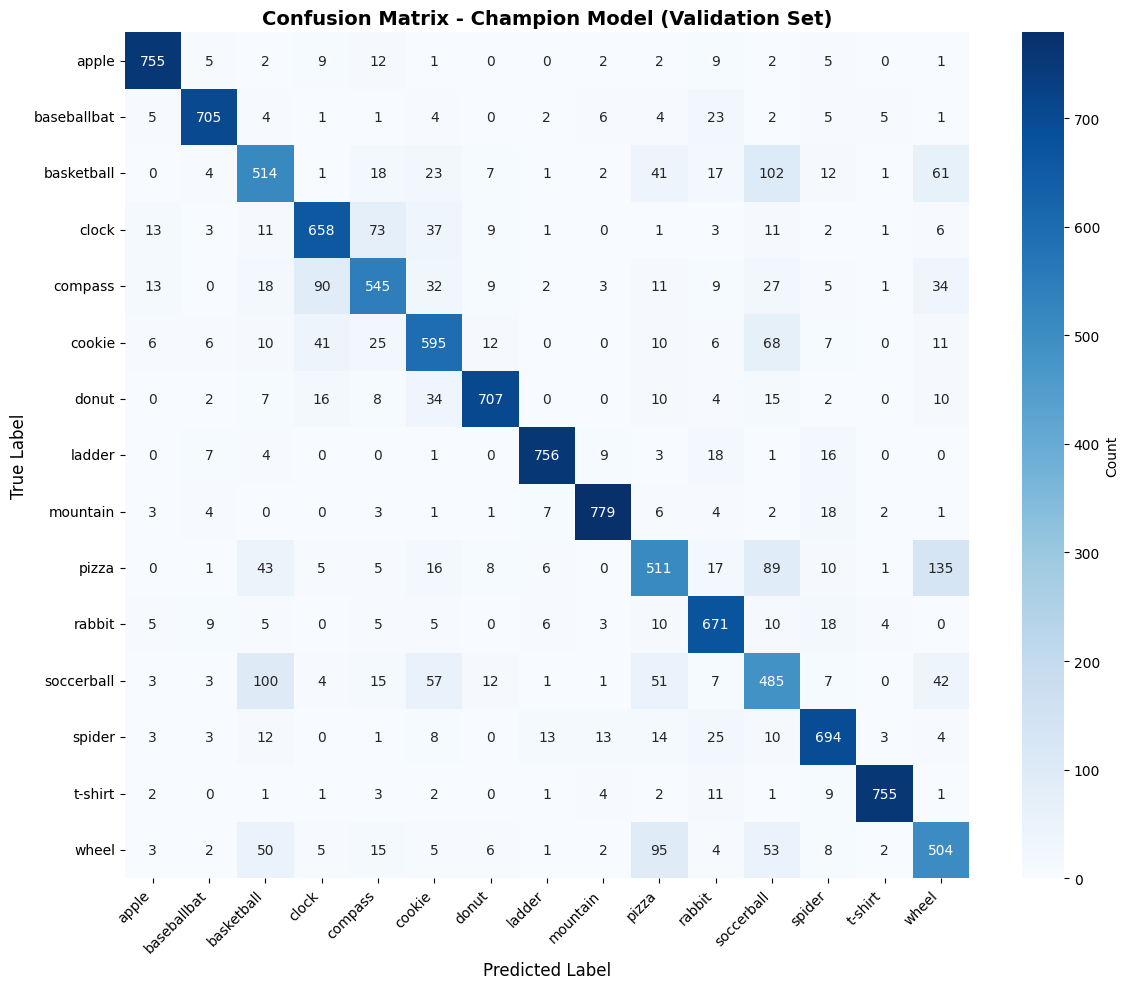

In [11]:
# ==========================================
# CONFUSION MATRIX ANALYSIS (Champion Model)
# ==========================================

# Get predictions on validation set
champion_model.eval()
val_preds = []
val_labels = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        if batch_x.dim() > 2:
            batch_x = batch_x.view(batch_x.size(0), -1)

        outputs = champion_model(batch_x)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(batch_y.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(val_labels, val_preds)

# Find top 2 most confused pairs
confusion_pairs = []
for i in range(len(CLASSES)):
    for j in range(i+1, len(CLASSES)):
        confusion_pairs.append((i, j, cm[i, j] + cm[j, i]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)
top_confused = confusion_pairs[:2]

print("\n" + "="*70)
print("TOP 2 MOST CONFUSED CLASS PAIRS")
print("="*70)
for idx, (i, j, count) in enumerate(top_confused, 1):
    print(f"{idx}. {CLASSES[i]} vs {CLASSES[j]}: {count} misclassifications")
print("="*70)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Champion Model (Validation Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

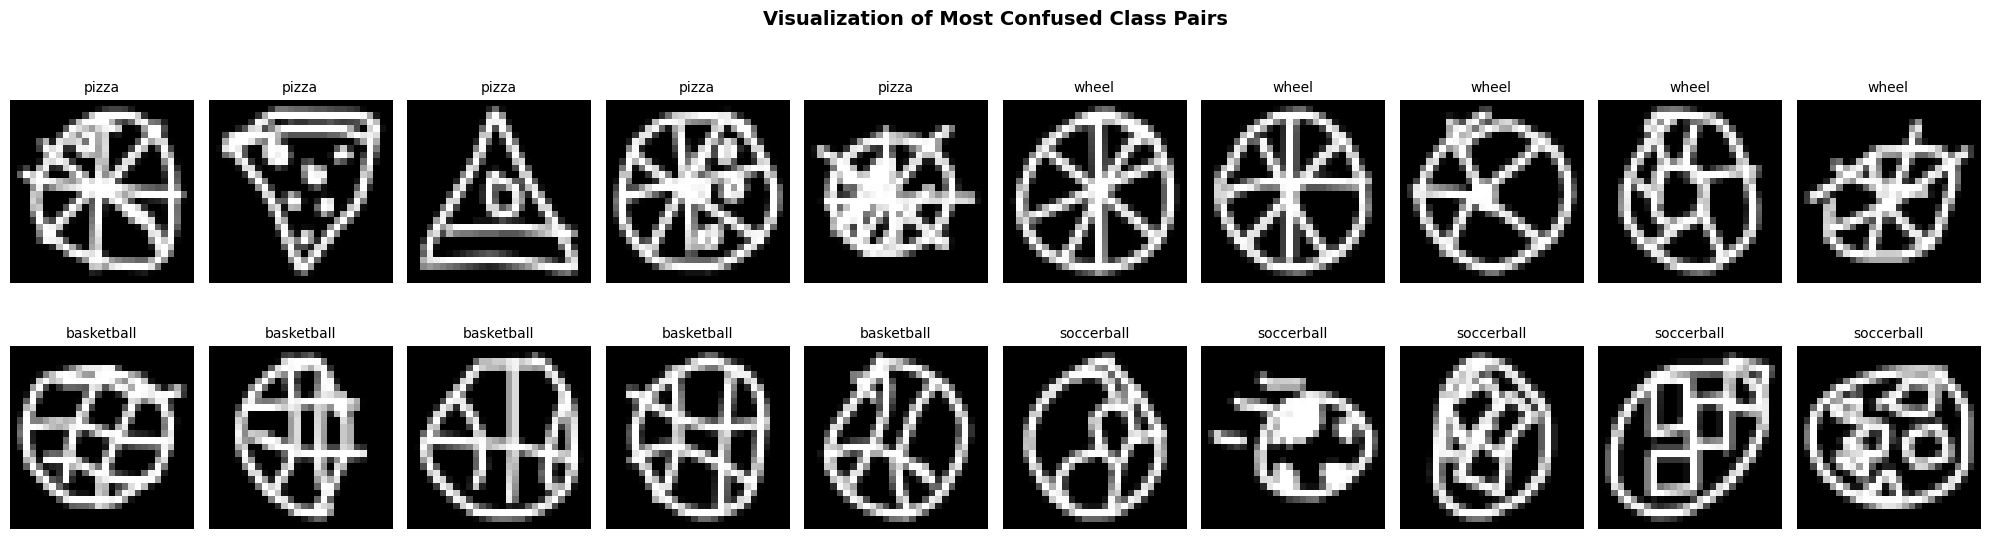

In [12]:
# ==========================================
# VISUALIZE CONFUSED CLASSES
# ==========================================

# Get sample images for confused pairs
fig, axes = plt.subplots(2, 10, figsize=(20, 6))

for pair_idx, (class_i, class_j, _) in enumerate(top_confused):
    # Get indices of these classes in validation set
    class_i_indices = [idx for idx, label in enumerate(val_labels) if label == class_i]
    class_j_indices = [idx for idx, label in enumerate(val_labels) if label == class_j]

    # Get some samples
    samples_i = class_i_indices[:5] if len(class_i_indices) >= 5 else class_i_indices
    samples_j = class_j_indices[:5] if len(class_j_indices) >= 5 else class_j_indices

    # Plot class_i samples
    for col, idx in enumerate(samples_i):
        img_idx = val_dataset.indices[idx] if hasattr(val_dataset, 'indices') else idx
        img = full_train_dataset.x[img_idx]
        if len(img.shape) == 1:
            img = img.reshape(28, 28)
        axes[pair_idx, col].imshow(img.numpy(), cmap='gray')
        axes[pair_idx, col].set_title(f'{CLASSES[class_i]}', fontsize=10)
        axes[pair_idx, col].axis('off')

    # Plot class_j samples
    for col, idx in enumerate(samples_j):
        img_idx = val_dataset.indices[idx] if hasattr(val_dataset, 'indices') else idx
        img = full_train_dataset.x[img_idx]
        if len(img.shape) == 1:
            img = img.reshape(28, 28)
        axes[pair_idx, col+5].imshow(img.numpy(), cmap='gray')
        axes[pair_idx, col+5].set_title(f'{CLASSES[class_j]}', fontsize=10)
        axes[pair_idx, col+5].axis('off')

plt.suptitle('Visualization of Most Confused Class Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confused_classes.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# ==========================================
# FINAL SUMMARY & ARCHITECTURE RATIONALE
# ==========================================

print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)
print(f"\nPancake: {pancake_results['params']:,} params, {pancake_results['best_val_acc']:.2f}% val acc")
print(f"Tower: {tower_results['params']:,} params, {tower_results['best_val_acc']:.2f}% val acc")
print(f"Champion: {champion_results['params']:,} params, {champion_results['best_val_acc']:.2f}% val acc")
print("="*70)


MODEL SUMMARY

Pancake: 5,842,959 params, 80.47% val acc
Tower: 536,847 params, 77.44% val acc
Champion: 1,230,991 params, 80.28% val acc


In [14]:
# ==========================================
# 4. MODEL ARCHITECTURES & TRAINING
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from collections import defaultdict

# Utility Functions
def count_parameters(model):
    """Count total trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Ensure input is flattened
        if batch_x.dim() > 2:
            batch_x = batch_x.view(batch_x.size(0), -1)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # Ensure input is flattened
            if batch_x.dim() > 2:
                batch_x = batch_x.view(batch_x.size(0), -1)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs, lr=0.001, weight_decay=1e-4,
                patience=7, model_name="model"):
    """Complete training loop with early stopping"""
    device = DEVICE
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"Parameters: {count_parameters(model):,}")
    print(f"{'='*60}\n")

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Early stopping and model saving
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"  ✓ New best validation accuracy! Model saved.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

        print()

    # Load best model
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    print(f"\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

    return {
        'model': model,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'params': count_parameters(model)
    }

# ==========================================
# PART A: THE PANCAKE (Wide & Shallow)
# ==========================================

class PancakeModel(nn.Module):
    """Wide shallow network: 1-2 layers with high neuron count"""
    def __init__(self, input_size=784, num_classes=15, hidden_size=2048, num_layers=2, dropout=0.3):
        super(PancakeModel, self).__init__()
        layers = []

        # First layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        # Optional second layer
        if num_layers >= 2:
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # Output layer
        layers.append(nn.Linear(hidden_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Create and train Pancake model
pancake_model = PancakeModel(input_size=784, num_classes=NUM_CLASSES, hidden_size=2048, num_layers=2, dropout=0.4)
pancake_results = train_model(pancake_model, train_loader, val_loader, epochs=40,
                              lr=0.001, weight_decay=1e-4, model_name="pancake")

# ==========================================
# PART B: THE TOWER (Deep & Narrow)
# ==========================================

class TowerModel(nn.Module):
    """Deep narrow network: 5+ layers with low neuron count"""
    def __init__(self, input_size=784, num_classes=15, hidden_size=256, num_layers=6, dropout=0.3):
        super(TowerModel, self).__init__()
        layers = []

        # Input layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        # Hidden layers
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # Output layer
        layers.append(nn.Linear(hidden_size, num_classes))

        self.network = nn.Sequential(*layers)

        # Initialize weights carefully to combat vanishing gradients
        self._initialize_weights()

    def _initialize_weights(self):
        """Xavier initialization for better gradient flow"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)

# Create and train Tower model
tower_model = TowerModel(input_size=784, num_classes=NUM_CLASSES, hidden_size=256, num_layers=6, dropout=0.4)
tower_results = train_model(tower_model, train_loader, val_loader, epochs=40,
                            lr=0.001, weight_decay=1e-4, model_name="tower")

# ==========================================
# PART C: THE CHAMPION (Best Architecture)
# ==========================================

class ChampionModel(nn.Module):
    """Optimized architecture combining best practices"""
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionModel, self).__init__()

        # Balanced architecture: moderate depth with moderate width
        # Using GELU activation for better performance
        self.network = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(1024, 768),
            nn.BatchNorm1d(768),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(256, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """He initialization for ReLU/GELU activations"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)

# Create and train Champion model
champion_model = ChampionModel(input_size=784, num_classes=NUM_CLASSES)
champion_results = train_model(champion_model, train_loader, val_loader, epochs=40,
                                lr=0.001, weight_decay=1e-3, model_name="champion")# Set the best model as the default model for inference
model = champion_results['model']



Training pancake
Parameters: 5,842,959

Epoch [1/40]
  Train Loss: 1.0694 | Train Acc: 65.07%
  Val Loss: 0.8737 | Val Acc: 71.39%
  ✓ New best validation accuracy! Model saved.

Epoch [2/40]
  Train Loss: 0.8319 | Train Acc: 72.28%
  Val Loss: 0.7966 | Val Acc: 74.08%
  ✓ New best validation accuracy! Model saved.

Epoch [3/40]
  Train Loss: 0.7351 | Train Acc: 75.45%
  Val Loss: 0.7479 | Val Acc: 75.81%
  ✓ New best validation accuracy! Model saved.

Epoch [4/40]
  Train Loss: 0.6715 | Train Acc: 77.44%
  Val Loss: 0.7456 | Val Acc: 76.18%
  ✓ New best validation accuracy! Model saved.

Epoch [5/40]
  Train Loss: 0.6120 | Train Acc: 79.44%
  Val Loss: 0.7236 | Val Acc: 77.23%
  ✓ New best validation accuracy! Model saved.

Epoch [6/40]
  Train Loss: 0.5705 | Train Acc: 80.67%
  Val Loss: 0.7130 | Val Acc: 77.42%
  ✓ New best validation accuracy! Model saved.

Epoch [7/40]
  Train Loss: 0.5330 | Train Acc: 81.89%
  Val Loss: 0.7043 | Val Acc: 78.01%
  ✓ New best validation accuracy! 

In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            # Flatten input if needed
            if X.dim() > 2:
                X = X.view(X.size(0), -1)
            elif X.dim() == 1:
                X = X.unsqueeze(0)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [16]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 2,290,063
  ✅ Parameter count is within limits.
